# E-commerce Delivery Performance & Customer Experience Analysis

### Domain : E-commerce

### Business Problem

E-commerce marketplaces rely heavily on efficient delivery operations to maintain customer satisfaction and platform reputation. Delays in order delivery can negatively impact customer experience, often reflected in lower review scores and reduced trust in the platform.

This project aims to analyze delivery performance within the marketplace to understand how delays affect customer satisfaction. The analysis focuses on identifying operational factors contributing to delivery delays, such as seller handling time, shipping duration, and geographic distance between sellers and customers. By evaluating the relationship between delivery performance and customer review scores, the project provides insights that can help improve logistics efficiency and enhance overall marketplace performance.

### Supporting Questions

1. How frequently do delivery delays occur across all orders in the marketplace?

2. How does delivery delay affect customer review scores?

3. Which sellers contribute the most to delayed deliveries?

4. Which geographic regions experience the highest delivery delays?

5. How does seller handling time impact overall delivery performance?

6. Option.)) Which sellers contribute the most to revenue loss due to delivery delays?

### Key Performance Indicators (KPIs)

The following KPIs are used to evaluate marketplace operations and customer experience:

-- Marketplace Activity

Total Orders

Total Revenue

Average Order Value

-- Delivery Performance

Average Delivery Time

Late Delivery Rate

-- Seller Operations

Average Seller Handling Time

-- Customer Experience

Average Review Score

Low Rating Rate (ratings ≤ 2)

These metrics help measure delivery efficiency and its impact on customer satisfaction.

### Dataset Overview

This project uses the Olist Brazilian E-commerce Public Dataset, which contains transactional data from a Brazilian e-commerce marketplace.

The dataset includes information about customers, orders, products, sellers, payments, reviews, and delivery timelines. It enables analysis of the complete order lifecycle, from purchase to delivery and customer feedback.

The dataset consists of the following tables:

1. Customers

2. Orders

3. Order Items

4. Order Payments

5. Order Reviews

6. Products

7. Sellers

8. Geolocation

These tables allow comprehensive analysis of marketplace performance, delivery efficiency, and customer satisfaction.

### The dataset follows a relational structure where multiple tables are connected using order_id, customer_id, and seller_id.

For this analysis, the Orders table is used as the base table and is joined with:

- Order Items → to calculate total order value and seller information  
- Customers → to extract customer location (state)  
- Reviews → to analyze customer satisfaction (review scores)  
- Products → to identify product categories  

These joins enable creation of a unified analytical dataset capturing delivery performance, seller behavior, revenue, and customer experience at the order level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
customers =  pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")

In [3]:
customers.shape

(99441, 5)

In [4]:
geolocation.shape

(1000163, 5)

In [5]:
order_items.shape

(112650, 7)

In [6]:
payments.shape

(103886, 5)

In [7]:
reviews.shape

(99224, 7)

In [8]:
orders.shape

(99441, 8)

In [9]:
products.shape

(32951, 9)

In [10]:
sellers.shape

(3095, 4)

In [11]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [12]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [15]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [16]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [18]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [19]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


# Data Cleaning

In [20]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [21]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [22]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [23]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [24]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [25]:
 orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [26]:
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']=pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']=pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date']=pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']=pd.to_datetime(orders['order_estimated_delivery_date'])

In [27]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [28]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [29]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [30]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [31]:
geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [33]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [34]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [35]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [36]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [37]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [38]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [39]:
customers.duplicated().sum()

np.int64(0)

In [40]:
geolocation.duplicated().sum()

np.int64(261831)

In [41]:
order_items.duplicated().sum()

np.int64(0)

In [42]:
payments.duplicated().sum()

np.int64(0)

In [43]:
reviews.duplicated().sum()

np.int64(0)

In [44]:
orders.duplicated().sum()

np.int64(0)

In [45]:
products.duplicated().sum()

np.int64(0)

In [46]:
sellers.duplicated().sum()

np.int64(0)

# Feature Engineering

In [47]:
#1️⃣ Filter Delivered Orders
orders = orders[orders["order_status"]=="delivered"]

In [48]:
#2️⃣ Seller Handling Time
orders["seller_handling_time"]= (orders["order_delivered_carrier_date"] - orders["order_approved_at"]).dt.days

In [49]:
#3️⃣ Shipping Time
orders["shipping_time"] = (orders["order_delivered_customer_date"] - orders["order_delivered_carrier_date"]).dt.days

In [50]:
#4️⃣ Total Delivery Time
orders["delivery_time"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

In [51]:
#5️⃣ Delivery Delay
orders["delivery_delay"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days

In [52]:
#6️⃣ Late Delivery Flag
orders["is_late_delivery"]= orders["delivery_delay"].apply(lambda x: 1 if x > 0 else 0)

In [53]:
#7️⃣ Extract Order Month (for trend analysis)
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

### Note:
For orders with multiple products or sellers, the first seller/category is used for analysis simplicity.

# 9. Create Final Analytical Dataset

In [54]:
#1️⃣ Calculate Order Revenue
order_revenue = order_items.groupby("order_id").agg(
    order_revenue=("price","sum"),
    freight_total=("freight_value","sum"),
    total_items=("order_item_id","count")
).reset_index()

In [55]:
order_revenue["total_order_value"]= (order_revenue["order_revenue"] + order_revenue["freight_total"])

In [56]:
#2️⃣ Join Revenue with Orders
orders_final = orders.merge(order_revenue, on ="order_id", how="left")

In [57]:
#3️⃣ Add Customer Information
orders_final = orders_final.merge(
    customers[["customer_id","customer_state"]],
    on = "customer_id",
    how = "left"
)

In [58]:
#4️⃣ Add Review Scores
orders_final = orders_final.merge(
    reviews[["order_id","review_score"]],
    on = "order_id",
    how = "left"
)

In [59]:
#5️⃣ Add Product Category
product_category = order_items.merge(
    products[["product_id","product_category_name"]],
    on = "product_id",
    how = "left"
)

In [60]:
product_category = product_category.groupby("order_id").agg(
    product_category = ("product_category_name","first")
).reset_index()

In [61]:
orders_final = orders_final.merge(product_category, on ="order_id",how = "left")

In [66]:
#6️⃣ Add Seller Information
seller_info = order_items.groupby("order_id").agg(
    seller_id = ("seller_id","first")
).reset_index()

In [67]:
orders_final = orders_final.merge(seller_info,on="order_id",how="left")

In [68]:
orders_final = orders_final.merge(
    sellers[["seller_id","seller_state"]],
    on = "seller_id",
    how = "left"
)

In [69]:
orders_final.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,seller_handling_time,shipping_time,...,order_month,order_revenue,freight_total,total_items,total_order_value,customer_state,review_score,product_category,seller_id,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,2017-10,29.99,8.72,1,38.71,SP,4.0,utilidades_domesticas,3504c0cb71d7fa48d967e0e4c94d59d9,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0.0,12.0,...,2018-07,118.70,22.76,1,141.46,BA,4.0,perfumaria,289cdb325fb7e7f891c38608bf9e0962,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.0,9.0,...,2018-08,159.90,19.22,1,179.12,GO,5.0,automotivo,4869f7a5dfa277a7dca6462dcf3b52b2,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,3.0,9.0,...,2017-11,45.00,27.20,1,72.20,RN,5.0,pet_shop,66922902710d126a0e7d26b0e3805106,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0.0,1.0,...,2018-02,19.90,8.72,1,28.62,SP,5.0,papelaria,2c9e548be18521d1c43cde1c582c6de8,SP


In [70]:
orders_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97007 entries, 0 to 97006
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       97007 non-null  object        
 1   customer_id                    97007 non-null  object        
 2   order_status                   97007 non-null  object        
 3   order_purchase_timestamp       97007 non-null  datetime64[ns]
 4   order_approved_at              96993 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97005 non-null  datetime64[ns]
 6   order_delivered_customer_date  96999 non-null  datetime64[ns]
 7   order_estimated_delivery_date  97007 non-null  datetime64[ns]
 8   seller_handling_time           96991 non-null  float64       
 9   shipping_time                  96998 non-null  float64       
 10  delivery_time                  96999 non-null  float64       
 11  delivery_delay 

In [71]:
orders_final.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'seller_handling_time', 'shipping_time', 'delivery_time',
       'delivery_delay', 'is_late_delivery', 'order_month', 'order_revenue',
       'freight_total', 'total_items', 'total_order_value', 'customer_state',
       'review_score', 'product_category', 'seller_id', 'seller_state'],
      dtype='object')

In [72]:
orders_final.shape

(97007, 23)

#  Exploratory Data Analysis (EDA)

### Q1. How frequently do delivery delays occur across all orders in the marketplace?

In [73]:
late_delivery_rate = orders_final["is_late_delivery"].mean()*100
late_delivery_rate

np.float64(6.764460296679621)

In [74]:
#2️⃣ Count Late vs On-Time Orders
orders_final["is_late_delivery"].value_counts() 

is_late_delivery
0    90445
1     6562
Name: count, dtype: int64

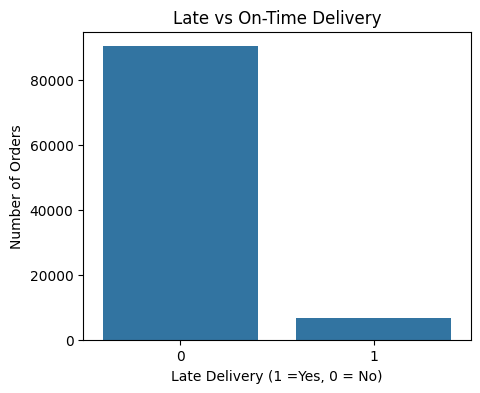

In [75]:
plt.figure(figsize=(5,4))
sns.countplot(x="is_late_delivery", data= orders_final)
plt.title("Late vs On-Time Delivery")
plt.xlabel("Late Delivery (1 =Yes, 0 = No)")
plt.ylabel("Number of Orders")
plt.show()

### Insight:
Approximately 6.76% of orders were delivered later than the estimated delivery date. While the majority of deliveries were completed on time, this delay rate indicates that a portion of orders still experience delivery inefficiencies, which may negatively affect customer satisfaction and marketplace reliability.

### Q2. How does delivery delay affect customer review scores?


In [76]:
orders_final.groupby("is_late_delivery")["review_score"].mean()

is_late_delivery
0    4.289999
1    2.271025
Name: review_score, dtype: float64

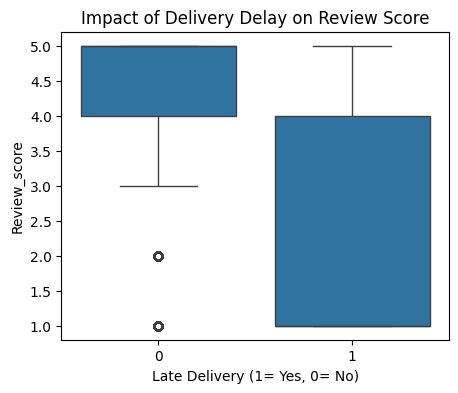

In [77]:
plt.figure(figsize=(5,4))
sns.boxplot(x="is_late_delivery", y="review_score", data=orders_final)
plt.title("Impact of Delivery Delay on Review Score")
plt.xlabel("Late Delivery (1= Yes, 0= No)")
plt.ylabel("Review_score")
plt.show()

### Insight:
Orders delivered on time have an average review score of 4.29, while orders delivered late receive a significantly lower average rating of 2.27. This indicates that delivery delays have a strong negative impact on customer satisfaction, highlighting the importance of efficient logistics and timely delivery for maintaining positive customer experiences in the marketplace.

### Q3. Which sellers contribute the most to delayed deliveries?

In [78]:
seller_delay = orders_final.groupby("seller_id").agg(
    total_orders = ("order_id", "count"),
    late_orders = ("is_late_delivery","sum")
)
seller_delay["delay_rate"] = seller_delay["late_orders"]/ seller_delay["total_orders"]
seller_delay = seller_delay[seller_delay["total_orders"] >=50]
seller_delay = seller_delay.sort_values("delay_rate", ascending = False)
seller_delay.head(10)

,total_orders,late_orders,delay_rate
seller_id,,,
54965bbe3e4f07ae045b90b0b8541f52,72,22,0.305556
beadbee30901a7f61d031b6b686095ad,63,15,0.238095
a49928bcdf77c55c6d6e05e09a9b4ca5,94,21,0.223404
712e6ed8aa4aa1fa65dab41fed5737e4,78,16,0.205128
06a2c3af7b3aee5d69171b0e14f0ee87,389,74,0.190231
002100f778ceb8431b7a1020ff7ab48f,50,9,0.180000
ea566164622c6b439516ab18062c42cd,50,9,0.180000
d20b021d3efdf267a402c402a48ea64b,79,14,0.177215
6039e27294dc75811c0d8a39069f52c0,63,11,0.174603


### Insight: To ensure reliable analysis, only sellers with at least 50 orders were considered when calculating delay rates. This prevents misleading results from sellers with very small order volumes.

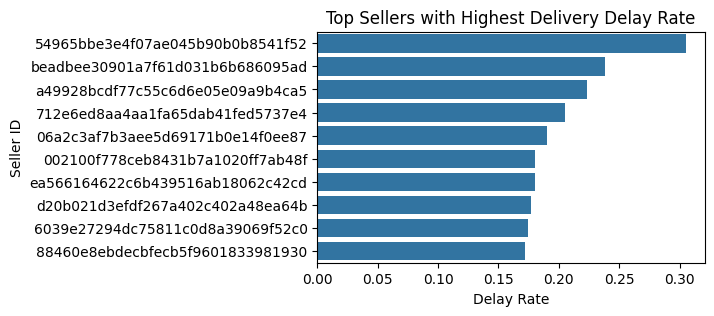

In [79]:
top_sellers = seller_delay.head(10)
plt.figure(figsize=(5,3))
sns.barplot(x=top_sellers["delay_rate"], y=top_sellers.index)
plt.title("Top Sellers with Highest Delivery Delay Rate")
plt.xlabel("Delay Rate")
plt.ylabel("Seller ID")
plt.show()

### Insight:
Among sellers with at least 50 orders, several sellers show significantly higher delivery delay rates. For example, the seller 54965bbe3e4f07ae045b90b0b8541f52 has a delay rate of approximately 30.6%, meaning nearly one-third of their orders were delivered late. This suggests that delivery inefficiencies may be concentrated among specific sellers and highlights the importance of monitoring seller performance to improve overall marketplace logistics.

### Q4. Which geographic regions experience the highest delivery delays?


In [80]:
state_delay = orders_final.groupby("customer_state").agg(
    total_orders=("order_id","count"),
    late_orders=("is_late_delivery","sum")
)
state_delay["delay_rate"] = state_delay["late_orders"]/ state_delay["total_orders"]
state_delay = state_delay[state_delay["total_orders"] >= 200]
state_delay = state_delay.sort_values("delay_rate",ascending= False)
state_delay.head(10)

,total_orders,late_orders,delay_rate
customer_state,,,
AL,401,86,0.214464
MA,721,125,0.173370
SE,335,51,0.152239
PI,477,66,0.138365
CE,1282,177,0.138066
BA,3273,400,0.122212
RJ,12420,1503,0.121014
PA,952,106,0.111345
ES,2004,214,0.106786


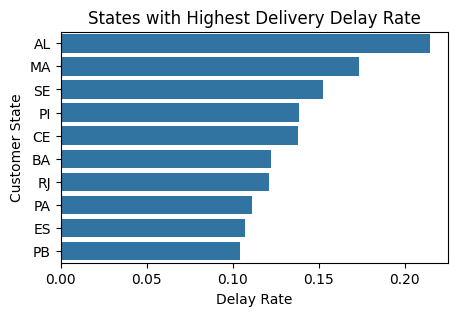

In [81]:
top_states = state_delay.head(10)
plt.figure(figsize=(5,3))
sns.barplot(x= top_states["delay_rate"], y = top_states.index)
plt.title("States with Highest Delivery Delay Rate")
plt.xlabel("Delay Rate")
plt.ylabel("Customer State")
plt.show()

### Insight:
Regional analysis shows that delivery delays are not evenly distributed across the marketplace. Alagoas (AL) has the highest delay rate at approximately 21.4%, followed by Maranhão (MA) with 17.3% and Sergipe (SE) with 15.2%. These results indicate that certain geographic regions experience significantly higher delivery delays, which may be due to longer shipping distances or weaker logistics infrastructure. Improving logistics performance in these regions could help reduce overall delivery delays and improve customer satisfaction.

### Q6. How does seller handling time impact overall delivery performance?

In [82]:
orders_final.groupby("is_late_delivery")["seller_handling_time"].mean()

is_late_delivery
0    2.098087
1    5.046792
Name: seller_handling_time, dtype: float64

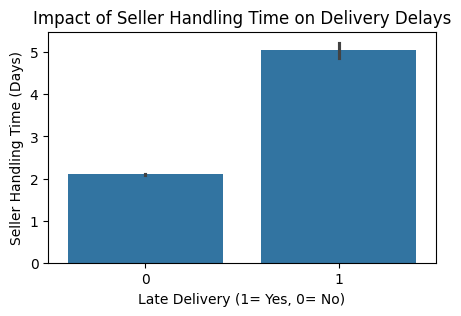

In [83]:
plt.figure(figsize=(5,3))
sns.barplot(x ="is_late_delivery", y="seller_handling_time", data=orders_final)
plt.title("Impact of Seller Handling Time on Delivery Delays")
plt.xlabel("Late Delivery (1= Yes, 0= No)")
plt.ylabel("Seller Handling Time (Days)")
plt.show()

### Insight:
Orders delivered on time have an average seller handling time of approximately 2.1 days, whereas delayed deliveries show a significantly higher average handling time of about 5.0 days. This suggests that slow order dispatch by sellers is a major contributor to delivery delays. Improving seller fulfillment efficiency could therefore play an important role in reducing overall delivery delays and improving customer satisfaction.

# Advanced Analysis

In [84]:
#1.Revenue Impact of Delivery Delays
revenue_impact = orders_final.groupby('is_late_delivery').agg(
    total_orders = ('order_id','count'),
    total_revenue = ('total_order_value','sum'),
    avg_order_value = ('total_order_value','mean')
).reset_index()
revenue_impact

,is_late_delivery,total_orders,total_revenue,avg_order_value
0,0,90445,14334267.49,158.486013
1,1,6562,1155398.06,176.074072


### Insight:
Late deliveries account for ~6.76% of total orders but contribute over ₹11.5L in revenue, with a higher average order value (₹176 vs ₹158 for on-time orders). This indicates that high-value orders are disproportionately affected by delays, increasing the financial risk. Delays are not only impacting customer experience but are also exposing high-revenue transactions to dissatisfaction.

In [85]:
#2.Customer Retention & Review Impact

# Orders per customer + avg review
customer_analysis = orders_final.groupby('customer_id').agg(
    total_orders= ('order_id','count'),
    avg_review_score = ('review_score','mean')
).reset_index()

# Customer segmentation
customer_analysis['customer_type'] = customer_analysis['total_orders'].apply(
    lambda x: 'repeat' if x >1 else 'one-time'
)

# Compare behavior
retention_analysis = customer_analysis.groupby('customer_type').agg(
    avg_review_score = ('avg_review_score','mean'),
    total_customers = ('customer_id','count')
).reset_index()

retention_analysis

,customer_type,avg_review_score,total_customers
0,one-time,4.156631,95953
1,repeat,4.075556,525


### Inisght:
The dataset shows a low repeat customer rate (~0.5%). However, this may be underestimated due to the limited time span of the dataset, which may not fully capture long-term customer behavior.

Interestingly, repeat customers do not have significantly higher satisfaction scores than one-time customers, suggesting that high ratings alone are not driving repeat purchases. This points to deeper factors such as delivery experience, pricing, or competition impacting customer loyalty.

In [86]:
#3.Seller Contribution to Delivery Delays

seller_analysis = orders_final.groupby('seller_id').agg(
    total_orders = ('order_id','count'),
    total_revenue = ('total_order_value','sum'),
    late_delivery_rate = ('is_late_delivery','mean')
).reset_index()

# Impact Score = Revenue × Delay Rate
seller_analysis['impact_score'] = (
    seller_analysis['total_revenue'] * seller_analysis['late_delivery_rate']
)

# Top 10 sellers causing maximum impact
top_sellers = seller_analysis.sort_values(
    by = 'impact_score',ascending= False
).head(10)

top_sellers

,seller_id,total_orders,total_revenue,late_delivery_rate,impact_score
830,4869f7a5dfa277a7dca6462dcf3b52b2,1117,247937.80,0.105640,26192.175828
854,4a3ca9315b744ce9f8e9374361493884,1742,236467.27,0.099885,23619.578060
1473,7c67e1448b00f6e969d365cea6b010ab,972,237775.26,0.092593,22016.227778
2893,fa1c13f2614d7b5c4749cbc52fecda94,571,200044.11,0.092820,18568.017215
1478,7d13fca15225358621be4086e1eb0964,555,122805.41,0.115315,14161.344577
2044,b1b3948701c5c72445495bd161b83a4c,14,21924.25,0.642857,14094.160714
186,1025f0e2d44d7041d6cf58b6550e0bfa,904,174579.80,0.079646,13904.585841
356,1f50f920176fa81dab994f9023523100,1389,143037.05,0.089993,12872.304716
2533,da8622b14eb17ae2831f4ac5b9dab84a,1311,188545.16,0.067124,12655.968024
1150,620c87c171fb2a6dd6e8bb4dec959fc6,726,127026.23,0.088154,11197.904573


### Inisght:
A small group of sellers contributes disproportionately to delayed revenue impact. The top 10 sellers alone generate significant delay-related revenue risk, with impact scores exceeding ₹26K. Notably, some sellers with relatively low order volumes exhibit extremely high delay rates (e.g., >60%), indicating operational inefficiencies. This suggests that targeting a limited set of high-impact sellers can significantly reduce overall delays.

In [88]:
#5.Regional Delay Impact
state_analysis = orders_final.groupby('customer_state').agg(
    total_orders = ('order_id','count'),
    late_delivery_rate = ('is_late_delivery','mean'),
    total_revenue = ('total_order_value','sum')
).reset_index()

# Impact score
state_analysis['impact_score'] = (
    state_analysis['total_revenue'] * state_analysis['late_delivery_rate']
)

state_analysis.sort_values(by='impact_score',ascending = False).head(10)

,customer_state,total_orders,late_delivery_rate,total_revenue,impact_score
25,SP,40712,0.044778,5799283.95,259680.060937
18,RJ,12420,0.121014,2063593.64,249724.737594
10,MG,11423,0.045610,1826486.53,83305.566150
4,BA,3273,0.122212,593408.37,72521.646196
22,RS,5382,0.061130,865877.26,52930.809836
23,SC,3560,0.082303,597067.83,49140.694997
5,CE,1282,0.138066,267267.58,36900.438112
7,ES,2004,0.106786,318466.51,34007.900768
17,PR,4942,0.040469,785095.06,31772.361797
15,PE,1604,0.095387,310257.50,29594.387469


### Inisght:
São Paulo (SP) contributes the highest revenue impact due to its large order volume, even with a relatively lower delay rate (4.5%). In contrast, states like RJ and BA exhibit significantly higher delay rates (12%), indicating operational inefficiencies. This suggests a dual strategy: optimize high-volume regions for maximum revenue protection and fix high-delay regions for operational improvement.

# SQL Analysis

In [89]:
conn = sqlite3.connect("olist_analysis.db")

In [90]:
orders_final["order_month"] = orders_final["order_month"].astype(str)
orders_final.to_sql("orders_final", conn, index = False, if_exists = "replace")

97007

### Q1. How frequently do delivery delays occur across all orders in the marketplace?

In [91]:
query = """
SELECT
    COUNT(CASE WHEN is_late_delivery = 1 THEN 1 END) * 100.0/ COUNT(*) AS late_delivery_rate
FROM orders_final;
"""
pd.read_sql(query,conn)

,late_delivery_rate
0,6.76446


### Insight
Approximately 6.76% of orders were delivered later than the estimated delivery date. While most deliveries occur on time, this delay rate indicates that a noticeable portion of orders experience delivery inefficiencies that could impact customer satisfaction.

### Q2. How does delivery delay affect customer review scores?

In [92]:
query = """
select is_late_delivery, avg(review_score) as avg_review_score
from orders_final
group by is_late_delivery;
"""
pd.read_sql(query,conn)

,is_late_delivery,avg_review_score
0,0,4.289999
1,1,2.271025


### Insight
Orders delivered on time have an average review score of 4.29, whereas delayed orders receive a significantly lower average rating of 2.27. This shows that delivery delays have a strong negative impact on customer satisfaction and overall customer experience.

### Q3. Which sellers contribute the most to delayed deliveries?

In [93]:
query = """
select seller_id, 
count(order_id) as total_orders,
sum(is_late_delivery) as late_orders,
sum(is_late_delivery)*1.0/ count(order_id) as delay_rate
from orders_final
group by seller_id
having count(order_id) >= 50
order by delay_rate desc
limit 10;
"""
pd.read_sql(query,conn)

,seller_id,total_orders,late_orders,delay_rate
0,54965bbe3e4f07ae045b90b0b8541f52,72,22,0.305556
1,beadbee30901a7f61d031b6b686095ad,63,15,0.238095
2,a49928bcdf77c55c6d6e05e09a9b4ca5,94,21,0.223404
3,712e6ed8aa4aa1fa65dab41fed5737e4,78,16,0.205128
4,06a2c3af7b3aee5d69171b0e14f0ee87,389,74,0.190231
5,ea566164622c6b439516ab18062c42cd,50,9,0.180000
6,002100f778ceb8431b7a1020ff7ab48f,50,9,0.180000
7,d20b021d3efdf267a402c402a48ea64b,79,14,0.177215
8,6039e27294dc75811c0d8a39069f52c0,63,11,0.174603
9,88460e8ebdecbfecb5f9601833981930,244,42,0.172131


### Insight
Several sellers show significantly higher delivery delay rates compared to others. For example, the seller 54965bbe3e4f07ae045b90b0b8541f52 has a delay rate of 30.6%, meaning nearly one-third of their orders were delivered late. This suggests that delivery delays may be concentrated among specific sellers and highlights the need for monitoring seller fulfillment performance

### Q4. Which geographic regions experience the highest delivery delays?

In [94]:
query = """
select customer_state,
count(order_id) as total_orders,
sum(is_late_delivery) as late_orders,
sum(is_late_delivery)*1.0/ count(order_id) as delay_rate
from orders_final
group by customer_state
having count(order_id) >= 200
order by delay_rate desc
limit 10;
"""
pd.read_sql(query,conn)

,customer_state,total_orders,late_orders,delay_rate
0,AL,401,86,0.214464
1,MA,721,125,0.173370
2,SE,335,51,0.152239
3,PI,477,66,0.138365
4,CE,1282,177,0.138066
5,BA,3273,400,0.122212
6,RJ,12420,1503,0.121014
7,PA,952,106,0.111345
8,ES,2004,214,0.106786
9,PB,518,54,0.104247


### Insight
Delivery delays vary across geographic regions. Alagoas (AL) shows the highest delay rate at approximately 21.4%, followed by Maranhão (MA) with 17.3% and Sergipe (SE) with 15.2%. These results suggest that logistics performance differs across regions, possibly due to shipping distance or infrastructure limitations.

### Q5. How does seller handling time impact overall delivery performance?

In [95]:
query = """
select is_late_delivery, 
avg(seller_handling_time) as avg_handling_time
from orders_final
group by is_late_delivery;
"""
pd.read_sql(query,conn)

,is_late_delivery,avg_handling_time
0,0,2.098087
1,1,5.046792


### Insight
Orders delivered on time have an average seller handling time of approximately 2.1 days, while delayed deliveries have a much higher average handling time of about 5 days. This indicates that slow order dispatch by sellers is a major contributor to delivery delays.

In [96]:
query= """
SELECT 
    seller_id,
    COUNT(order_id) AS total_orders,
    SUM(total_order_value) AS total_revenue,
    AVG(is_late_delivery) AS late_delivery_rate,
    SUM(total_order_value * is_late_delivery) AS delayed_revenue
FROM orders_final
GROUP BY seller_id
HAVING COUNT(order_id) > 50
ORDER BY delayed_revenue DESC
LIMIT 10;
"""
pd.read_sql(query,conn)

,seller_id,total_orders,total_revenue,late_delivery_rate,delayed_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1117,247937.80,0.105640,26999.78
1,4a3ca9315b744ce9f8e9374361493884,1742,236467.27,0.099885,25072.39
2,7c67e1448b00f6e969d365cea6b010ab,972,237775.26,0.092593,21512.08
3,7d13fca15225358621be4086e1eb0964,555,122805.41,0.115315,15295.37
4,fa1c13f2614d7b5c4749cbc52fecda94,571,200044.11,0.092820,15075.46
5,1025f0e2d44d7041d6cf58b6550e0bfa,904,174579.80,0.079646,14281.76
6,da8622b14eb17ae2831f4ac5b9dab84a,1311,188545.16,0.067124,13260.81
7,1f50f920176fa81dab994f9023523100,1389,143037.05,0.089993,11659.72
8,955fee9216a65b617aa5c0531780ce60,1257,156806.67,0.061257,11418.15
9,f7ba60f8c3f99e7ee4042fdef03b70c4,218,73162.82,0.137615,9862.99


### Insight:
A small group of sellers contributes disproportionately to revenue affected by delivery delays. The top sellers generate significant delayed revenue, indicating that focusing on high-volume sellers with moderate delay rates can have a larger financial impact than targeting only high-delay but low-volume sellers.

# Business Insights & Recommendations

### Key Business Insights

### 1. Delivery delays have a disproportionate business impact: 
Although only ~6.7% of orders are delayed, they significantly reduce customer satisfaction (avg rating drops from 4.29 to 2.27), indicating that even a small delay rate poses a major risk to customer experience and platform trust.

### 2. Delivery performance is a key driver of customer satisfaction:
There is a strong negative relationship between delivery delays and review scores, confirming that timely delivery is critical for maintaining high customer ratings.

### 3. High-volume sellers drive the majority of delayed revenue:  
A small group of high-volume sellers contributes disproportionately to delayed revenue. Even with moderate delay rates, their large order volumes make them the highest financial risk segment.

### 4. Delivery delays are concentrated among specific sellers:  
Certain sellers exhibit delay rates exceeding 30%, indicating operational inefficiencies that are not evenly distributed across the marketplace.

### 5. Regional disparities highlight logistics inefficiencies:  
States such as AL, MA, and SE show significantly higher delay rates, suggesting potential issues related to logistics infrastructure, delivery distance, or courier performance.

### 6. Seller handling time is a major operational bottleneck:  
Delayed orders have significantly higher seller handling time (~5 days vs ~2 days), indicating that slow order processing is a key contributor to delivery delays.

### Business Recommendations

### 1. Target high-impact sellers for operational improvement  
Identify top sellers contributing to delayed revenue and enforce stricter dispatch SLAs, along with penalties or monitoring for consistently high delay rates.

### 2. Optimize logistics in high-delay regions  
Focus on improving delivery efficiency in high-delay states (AL, MA, SE) by evaluating courier performance and exploring alternative logistics partners.

### 3. Implement seller performance benchmarking  
Introduce performance tiers based on delay rate and handling time, with incentives for high-performing sellers and corrective actions for underperforming sellers.

### 4. Reduce seller handling time  
Encourage faster order processing through operational guidelines, automated workflows, or penalties for excessive handling delays.

### 5. Develop real-time performance monitoring dashboards  
Track key metrics such as late delivery rate, seller handling time, and delayed revenue to enable proactive identification and resolution of operational issues.

#  Project Conclusion

This analysis demonstrates that delivery delays, although affecting a relatively small percentage of orders (~6.7%), have a significant negative impact on customer satisfaction and revenue risk. The findings highlight that seller handling time and a small group of high-volume sellers are the primary drivers of delays. Additionally, regional inefficiencies further contribute to inconsistent delivery performance. Addressing these operational bottlenecks through targeted seller interventions and logistics optimization can significantly improve delivery efficiency and protect high-value revenue streams.

In [98]:
orders_final.to_csv("orders_data.csv", index=False)